In [32]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [2]:


# Download latest version
path = kagglehub.competition_download('playground-series-s6e3')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e3


In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')

In [4]:
df = pd.concat([df_train,df_test])
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  str    
 2   SeniorCitizen     848849 non-null  int64  
 3   Partner           848849 non-null  str    
 4   Dependents        848849 non-null  str    
 5   tenure            848849 non-null  int64  
 6   PhoneService      848849 non-null  str    
 7   MultipleLines     848849 non-null  str    
 8   InternetService   848849 non-null  str    
 9   OnlineSecurity    848849 non-null  str    
 10  OnlineBackup      848849 non-null  str    
 11  DeviceProtection  848849 non-null  str    
 12  TechSupport       848849 non-null  str    
 13  StreamingTV       848849 non-null  str    
 14  StreamingMovies   848849 non-null  str    
 15  Contract          848849 non-null  str    
 16  PaperlessBilling  848849 non-null  s

In [6]:
df.isnull().sum()

id                       0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
Churn               254655
dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

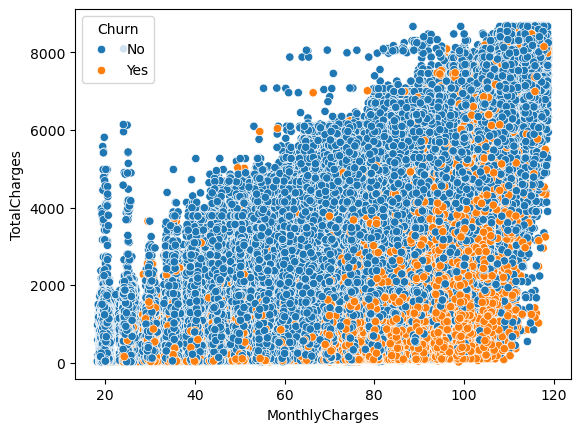

In [7]:
sns.scatterplot(df, x='MonthlyCharges', y ='TotalCharges',hue='Churn')

In [8]:
for col in df.columns:
    print(f'{col} : {df[col].nunique()}')

id : 848849
gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 72
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1939
TotalCharges : 35209
Churn : 2


In [9]:
categorical_features = df.select_dtypes(include=['str']).columns.tolist()

In [10]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [11]:
for col in categorical_features:
    print(f'{col} : {df[col].unique()}')

gender : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
PhoneService : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
TechSupport : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingTV : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract : <StringArray>
['One year', 'Two y

In [12]:
for col in categorical_features:
    if df[col].nunique() == 2:
        df[col] = df[col].apply(lambda x : 1 if x == 'Yes' else 0).astype('int64')

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  int64  
 2   SeniorCitizen     848849 non-null  int64  
 3   Partner           848849 non-null  int64  
 4   Dependents        848849 non-null  int64  
 5   tenure            848849 non-null  int64  
 6   PhoneService      848849 non-null  int64  
 7   MultipleLines     848849 non-null  str    
 8   InternetService   848849 non-null  str    
 9   OnlineSecurity    848849 non-null  str    
 10  OnlineBackup      848849 non-null  str    
 11  DeviceProtection  848849 non-null  str    
 12  TechSupport       848849 non-null  str    
 13  StreamingTV       848849 non-null  str    
 14  StreamingMovies   848849 non-null  str    
 15  Contract          848849 non-null  str    
 16  PaperlessBilling  848849 non-null  i

In [14]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,1,1,29,1,No,DSL,Yes,...,Yes,Yes,No,No,One year,1,Mailed check,60.10,1653.85,0
1,1,0,0,1,1,58,1,No,DSL,Yes,...,No,Yes,Yes,No,Two year,0,Credit card (automatic),69.50,3778.20,0
2,2,0,0,1,0,58,1,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,1,Electronic check,100.40,5841.35,0
3,3,0,0,0,0,1,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,69.70,70.70,1
4,4,0,0,0,0,1,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.45,70.45,1


In [15]:
training_data = df[0:len(df_train)]
testing_data = df[len(df_train):]
testing_data = testing_data.drop(columns='Churn')

In [16]:
training_data = training_data.drop(columns='id')
testing_data = testing_data.drop(columns='id')

In [17]:
training_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,1,29,1,No,DSL,Yes,No,Yes,Yes,No,No,One year,1,Mailed check,60.10,1653.85,0
1,0,0,1,1,58,1,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,0,Credit card (automatic),69.50,3778.20,0
2,0,0,1,0,58,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,1,Electronic check,100.40,5841.35,0
3,0,0,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,69.70,70.70,1
4,0,0,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.45,70.45,1


In [18]:
testing_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,72,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Electronic check,115.55,8061.50
1,0,0,1,0,71,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),19.80,1336.50
2,0,0,0,0,12,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Bank transfer (automatic),55.55,633.55
3,0,0,1,1,71,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,0,Credit card (automatic),84.10,6457.15
4,0,0,0,0,15,1,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,0,Electronic check,90.35,1233.65


In [19]:
X = training_data.drop(columns='Churn')
y = training_data['Churn']

In [20]:
X_temp, X_test, y_temp, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
X_train, X_val, y_train,y_val = train_test_split(X_temp,y_temp, test_size=0.25,random_state=42,stratify=y_temp)

len(X_train), len(X_test),len(X_val)

(356516, 118839, 118839)

In [21]:
training_data.select_dtypes(include=['number']).columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='str')

In [22]:
training_data.select_dtypes(include=['str']).columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='str')

In [23]:
features_numericas = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']
features_categoricas = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod']

preprocessing = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),features_numericas),
        ('cat',OneHotEncoder(handle_unknown='ignore'), features_categoricas)
    ],
    remainder='passthrough'
)

X_train_processed = preprocessing.fit_transform(X_train)
X_test_processed = preprocessing.transform(X_test)
X_val_processed = preprocessing.transform(X_val)


In [24]:
colunas_novas = preprocessing.get_feature_names_out()
colunas_novas

array(['num__gender', 'num__SeniorCitizen', 'num__Partner',
       'num__Dependents', 'num__tenure', 'num__PhoneService',
       'num__PaperlessBilling', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__StreamingTV_Yes', 'cat__StreamingMovies_No',
       'cat__StreamingMovies_No internet 

In [26]:
X_train = pd.DataFrame(data=X_train_processed, columns=colunas_novas)
X_test = pd.DataFrame(data=X_test_processed, columns=colunas_novas)
X_val = pd.DataFrame(data=X_val_processed, columns=colunas_novas)

In [ ]:
clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method='hist',
    early_stopping_rounds=5,
)

clf.fit(X_train, y_train, 
        eval_set=[(X_val, y_val)],
        verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [ ]:

preds = clf.predict(X_test)

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.65      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



In [38]:
sub = pd.DataFrame({
    "Id": range(594194, 594194 + len(preds)), 
    "Churn": preds
})

sub.to_csv('submission.csv', index=False)